## Research Question: What proportion of petitions achieve significant engagement thresholds?

Digital petition platforms allow citizens to influence policymaking by mobilizing public support online. On the UK Government’s e-petition platform (petition.parliament.uk), a petition receives a government response if it gains **10,000 signatures**, and becomes eligible for **parliamentary debate** if it surpasses **100,000 signatures**.

This analysis explores how many petitions actually meet these thresholds. By combining data from both the live and archived petition datasets, we assess the overall effectiveness of the platform in converting citizen participation into institutional recognition. The following code blocks provide statistical breakdowns and visualizations that answer this research question.


### Load and Prepare Petition Data

To analyze engagement levels across all petitions, we combine data from both the live and archived UK petition datasets. This gives a comprehensive view of citizen participation from 2011. We standardize column names for consistency and prepare the data for analysis.


In [1]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [4]:
df_live = pd.read_csv("petitions-live.csv")
df_archive = pd.read_csv("petitions-archive.csv")

df_all = pd.concat([df_live, df_archive], ignore_index=True)


In [7]:
df_all.columns = df_all.columns.str.strip().str.lower().str.replace(" ", "_")
df_all = df_all.rename(columns={"signatures_count": "signature_count"})

In [8]:
total_petitions = len(df_all)
gov_response_count = (df_all['signature_count'] >= 10000).sum()
debate_count = (df_all['signature_count'] >= 100000).sum()

In [9]:
print(f"Total petitions (combined): {total_petitions}")
print(f"Petitions ≥10,000: {gov_response_count} ({(gov_response_count/total_petitions)*100:.2f}%)")
print(f"Petitions ≥100,000: {debate_count} ({(debate_count/total_petitions)*100:.2f}%)")

Total petitions (combined): 56426
Petitions ≥10,000: 1111 (1.97%)
Petitions ≥100,000: 204 (0.36%)


### Distribution of Petition Signature Counts (Log Scale)

This histogram visualizes the distribution of signature counts across all petitions. Due to the extreme variation in signature totals, we apply a log10 transformation to better reveal patterns. Most petitions receive relatively few signatures, with only a small number gaining large-scale public support.


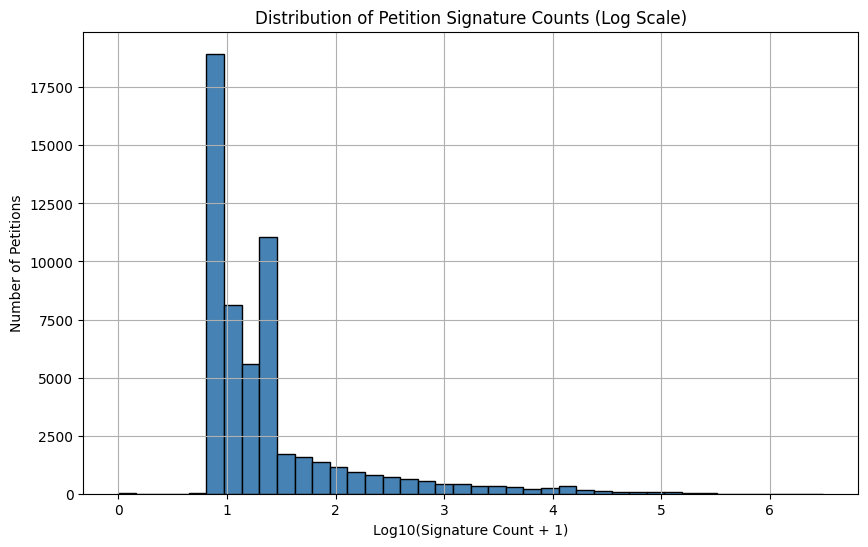

In [10]:
df_all['log_signature_count'] = np.log10(df_all['signature_count'] + 1)

plt.figure(figsize=(10, 6))
plt.hist(df_all['log_signature_count'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Petition Signature Counts (Log Scale)')
plt.xlabel('Log10(Signature Count + 1)')
plt.ylabel('Number of Petitions')
plt.grid(True)
plt.show()


### Petition Threshold Outcomes

We classify petitions into three categories based on their signature counts:

- **<10,000**: Did not trigger any government response  
- **10,000–99,999**: Triggered an official response  
- **≥100,000**: Qualified for parliamentary debate

This pie chart highlights the proportions of petitions in each category, showing that only a small fraction of public efforts result in institutional attention.


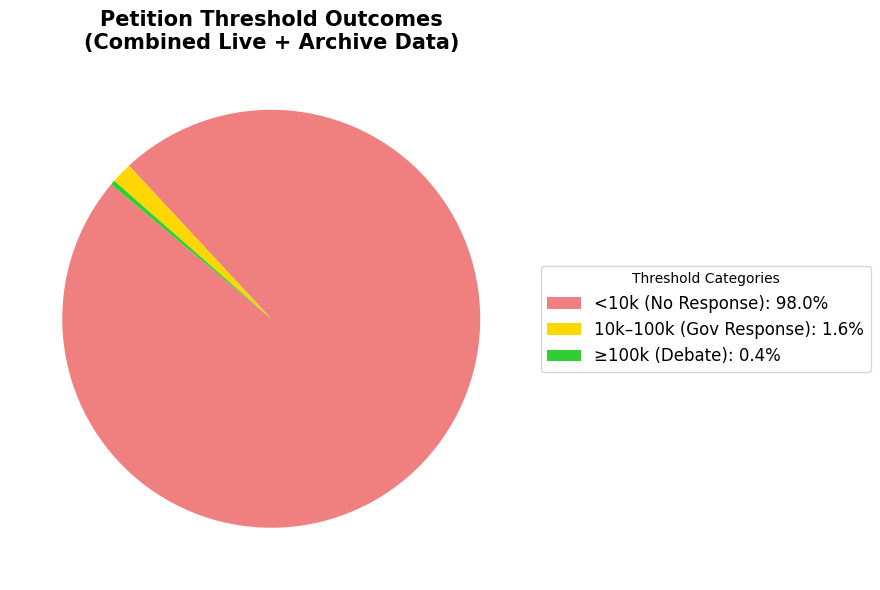

In [19]:
labels = ['<10k (No Response)', '10k–100k (Gov Response)', '≥100k (Debate)']
sizes = [below_10k, between_10k_100k, above_100k]
colors = ['#f08080', '#ffd700', '#32cd32']

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts = ax.pie(
    sizes,
    startangle=140,
    colors=colors,
    labels=None,  
)

plt.title('Petition Threshold Outcomes\n(Combined Live + Archive Data)', fontsize=15, weight='bold')

ax.legend(
    wedges,
    [f"{label}: {value/total_petitions:.1%}" for label, value in zip(labels, sizes)],
    title="Threshold Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

plt.tight_layout()
plt.show()


### Engagement by Petition Status

This summary shows how petitions perform across different status categories (e.g., open, closed, rejected), focusing on how many reach the 10,000 or 100,000 signature thresholds. This helps reveal whether petition visibility or platform filtering affects engagement success.


In [12]:
# Count of petitions grouped by state and threshold
thresholds_by_state = df_all.groupby('state')['signature_count'].agg([
    ('Total Petitions', 'count'),
    ('≥10k', lambda x: (x >= 10000).sum()),
    ('≥100k', lambda x: (x >= 100000).sum())
])

print(thresholds_by_state)


          Total Petitions  ≥10k  ≥100k
state                                 
closed              13761  1024    189
open                 1840    87     15
rejected            40825     0      0
